In [1]:
!git clone https://github.com/Anand-786/llm-quantization-thesis.git
%cd /content/llm-quantization-thesis
!pip install -q matplotlib pandas

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/llm-quantization-thesis/results/task05", exist_ok=True)

# Sanity: confirm the three .pt files are present on Drive
SCALES_DIR = "/content/drive/MyDrive/thesis_results/act_scales"
for size in ["2.7b", "6.7b", "13b"]:
    p = f"{SCALES_DIR}/opt-{size}.pt"
    assert os.path.exists(p), f"missing: {p}"
    print(f"  ok  {p}  ({os.path.getsize(p)/1024**2:.1f} MB)")

Cloning into 'llm-quantization-thesis'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (208/208), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 208 (delta 90), reused 174 (delta 56), pack-reused 0 (from 0)
Receiving objects: 100% (208/208), 4.90 MiB | 10.49 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/llm-quantization-thesis
Mounted at /content/drive
  ok  /content/drive/MyDrive/thesis_results/act_scales/opt-2.7b.pt  (2.9 MB)
  ok  /content/drive/MyDrive/thesis_results/act_scales/opt-6.7b.pt  (4.6 MB)
  ok  /content/drive/MyDrive/thesis_results/act_scales/opt-13b.pt  (7.1 MB)


In [2]:
import re
import torch
import pandas as pd

LAYER_RE = re.compile(r"model\.decoder\.layers\.(\d+)\.(.+)")

def site_type(suffix: str) -> str:
    if suffix.startswith("self_attn.q_proj"):
        return "q_proj"
    if suffix == "fc1" or suffix.startswith("fc1"):
        return "fc1"
    return "other"

def severity_table(scales_path: str, model_tag: str) -> pd.DataFrame:
    raw = torch.load(scales_path, map_location="cpu")
    rows = []
    for name, vec in raw.items():
        m = LAYER_RE.match(name)
        if not m:
            continue
        layer_idx = int(m.group(1))
        st = site_type(m.group(2))
        if st == "other":
            continue  # only the smoothed sites — q_proj input and fc1 input
        v = vec.float().abs()
        s_max = v.max().item()
        s_med = v.median().item()
        s_mean = v.mean().item()
        s_p99 = torch.quantile(v, 0.99).item()
        rows.append(dict(
            model=model_tag,
            layer=layer_idx,
            site=st,
            n_channels=v.numel(),
            max=s_max,
            median=s_med,
            mean=s_mean,
            p99=s_p99,
            severity=s_max / max(s_med, 1e-12),
            p99_over_median=s_p99 / max(s_med, 1e-12),
        ))
    return pd.DataFrame(rows).sort_values(["site", "layer"]).reset_index(drop=True)

# Quick test on 2.7B
df_test = severity_table(f"{SCALES_DIR}/opt-2.7b.pt", "opt-2.7b")
print(df_test.head(8))
print("\nlayers found:", df_test["layer"].nunique(), " sites per layer:", df_test.groupby("layer").size().unique())

      model  layer site  n_channels       max    median      mean       p99  \
0  opt-2.7b      0  fc1        2560  48.03125  1.325195  1.445988  2.735176   
1  opt-2.7b      1  fc1        2560  49.53125  2.136719  2.247897  3.365331   
2  opt-2.7b      2  fc1        2560  49.43750  1.908203  1.997465  2.909004   
3  opt-2.7b      3  fc1        2560  49.65625  1.654297  1.715354  2.407147   
4  opt-2.7b      4  fc1        2560  49.65625  1.735352  1.800177  2.485721   
5  opt-2.7b      5  fc1        2560  49.71875  1.865234  1.929969  2.697714   
6  opt-2.7b      6  fc1        2560  49.71875  2.033203  2.094117  2.898182   
7  opt-2.7b      7  fc1        2560  49.59375  2.185547  2.248482  3.047421   

    severity  p99_over_median  
0  36.244657         2.063979  
1  23.180987         1.575000  
2  25.907881         1.524473  
3  30.016529         1.455088  
4  28.614519         1.432402  
5  26.655497         1.446314  
6  24.453410         1.425427  
7  22.691689         1.394351  


In [3]:
frames = []
for size, tag in [("2.7b", "opt-2.7b"), ("6.7b", "opt-6.7b"), ("13b", "opt-13b")]:
    df = severity_table(f"{SCALES_DIR}/opt-{size}.pt", tag)
    print(f"{tag:>10}: {len(df)} sites, severity median={df['severity'].median():.2f}, "
          f"min={df['severity'].min():.2f}, max={df['severity'].max():.2f}, spread={df['severity'].max()/df['severity'].min():.2f}x")
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
csv_path = "/content/llm-quantization-thesis/results/task05/outlier_severity.csv"
all_df.to_csv(csv_path, index=False)
print(f"\nsaved -> {csv_path}  ({len(all_df)} rows)")

  opt-2.7b: 64 sites, severity median=15.02, min=2.77, max=36.24, spread=13.09x
  opt-6.7b: 64 sites, severity median=21.25, min=2.62, max=59.89, spread=22.89x
   opt-13b: 80 sites, severity median=23.25, min=1.77, max=82.08, spread=46.33x

saved -> /content/llm-quantization-thesis/results/task05/outlier_severity.csv  (208 rows)


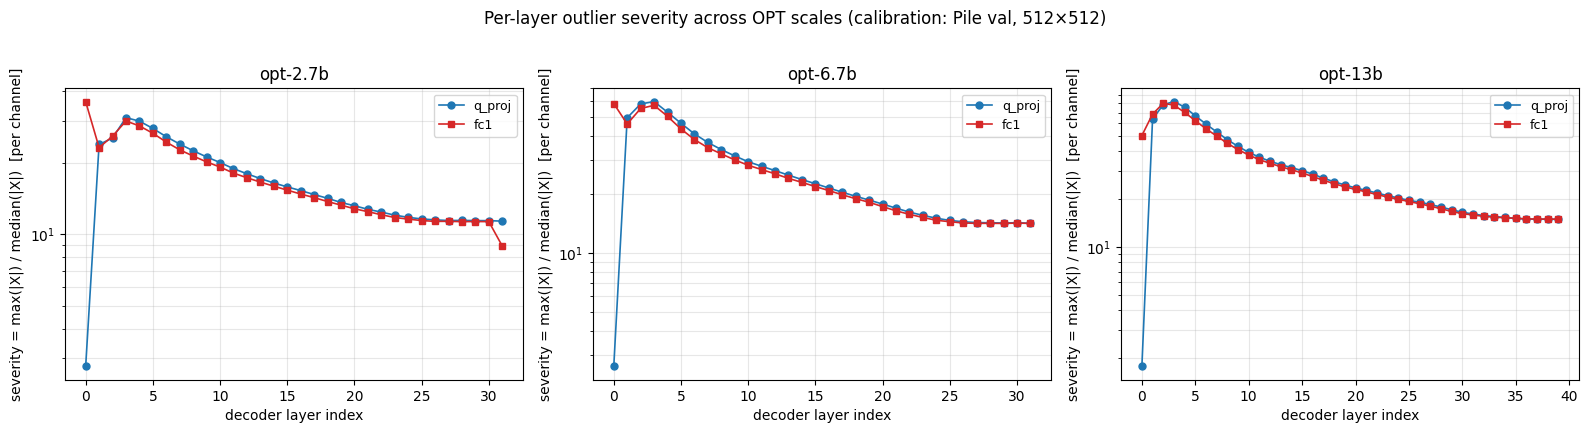

saved -> /content/llm-quantization-thesis/results/task05/outlier_severity_per_layer.png


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=False)
for ax, (tag, df) in zip(axes, [(t, all_df[all_df.model == t]) for t in ["opt-2.7b", "opt-6.7b", "opt-13b"]]):
    for site, marker, color in [("q_proj", "o", "#1f77b4"), ("fc1", "s", "#d62728")]:
        sub = df[df.site == site].sort_values("layer")
        ax.plot(sub["layer"], sub["severity"], marker=marker, color=color,
                label=site, linewidth=1.2, markersize=5)
    ax.set_xlabel("decoder layer index")
    ax.set_ylabel("severity = max(|X|) / median(|X|)  [per channel]")
    ax.set_title(tag)
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best", fontsize=9)

fig.suptitle("Per-layer outlier severity across OPT scales (calibration: Pile val, 512×512)", y=1.02)
fig.tight_layout()
out_png = "/content/llm-quantization-thesis/results/task05/outlier_severity_per_layer.png"
fig.savefig(out_png, dpi=140, bbox_inches="tight")
plt.show()
print(f"saved -> {out_png}")

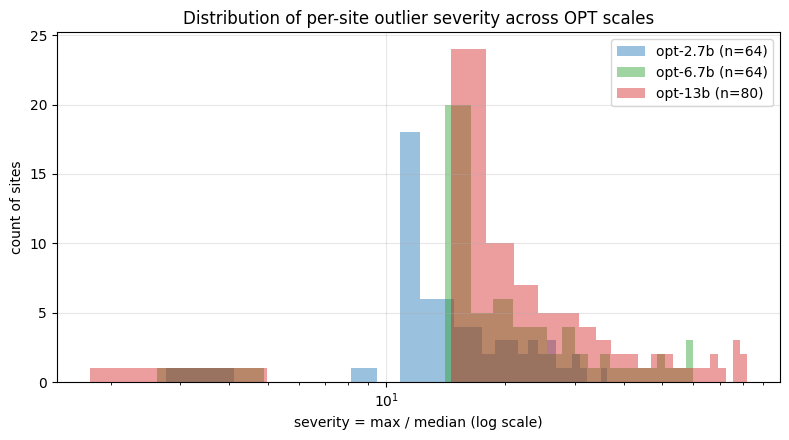


Severity summary per model:
           min  median    max  spread_max_over_min
model                                             
opt-13b   1.77   23.25  82.08                46.33
opt-2.7b  2.77   15.02  36.24                13.09
opt-6.7b  2.62   21.25  59.89                22.89


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
for tag, color in [("opt-2.7b", "#1f77b4"), ("opt-6.7b", "#2ca02c"), ("opt-13b", "#d62728")]:
    sub = all_df[all_df.model == tag]
    ax.hist(sub["severity"], bins=25, alpha=0.45, label=f"{tag} (n={len(sub)})", color=color)
ax.set_xscale("log")
ax.set_xlabel("severity = max / median (log scale)")
ax.set_ylabel("count of sites")
ax.set_title("Distribution of per-site outlier severity across OPT scales")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
out_png = "/content/llm-quantization-thesis/results/task05/outlier_severity_histogram.png"
fig.savefig(out_png, dpi=140, bbox_inches="tight")
plt.show()

# Per-model summary
summary = (
    all_df.groupby("model")["severity"]
    .agg(["min", "median", "max", lambda s: s.max() / s.min()])
    .rename(columns={"<lambda_0>": "spread_max_over_min"})
)
print("\nSeverity summary per model:")
print(summary.round(2))
summary.to_csv("/content/llm-quantization-thesis/results/task05/severity_summary.csv")

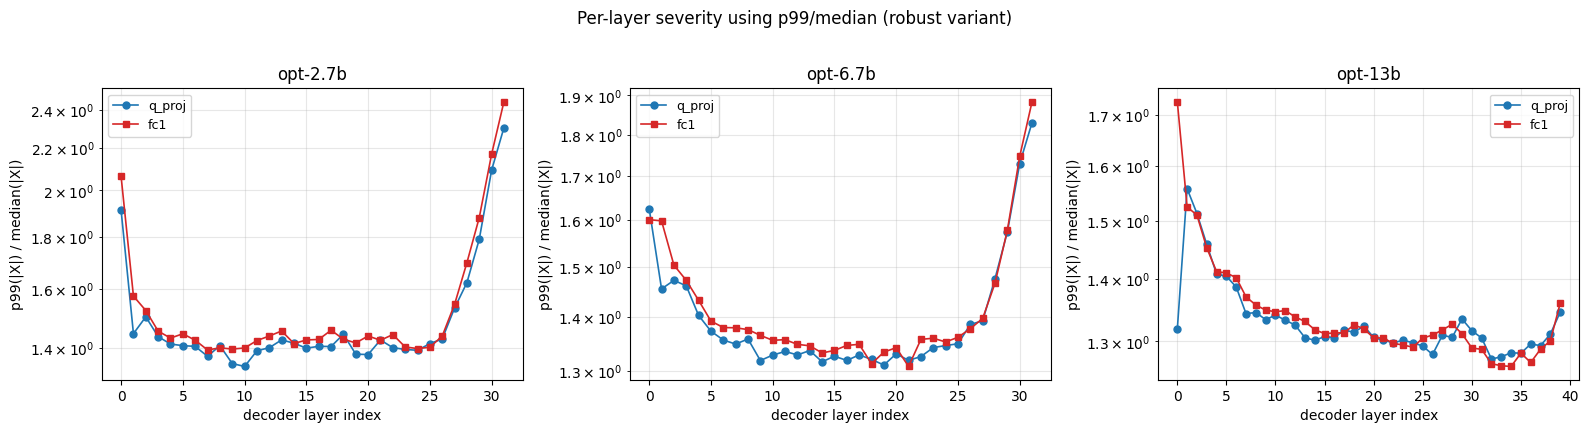

saved -> /content/llm-quantization-thesis/results/task05/outlier_severity_p99_per_layer.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=False)
for ax, tag in zip(axes, ["opt-2.7b", "opt-6.7b", "opt-13b"]):
    df = all_df[all_df.model == tag]
    for site, marker, color in [("q_proj", "o", "#1f77b4"), ("fc1", "s", "#d62728")]:
        sub = df[df.site == site].sort_values("layer")
        ax.plot(sub["layer"], sub["p99_over_median"], marker=marker, color=color,
                label=site, linewidth=1.2, markersize=5)
    ax.set_xlabel("decoder layer index")
    ax.set_ylabel("p99(|X|) / median(|X|)")
    ax.set_title(tag)
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best", fontsize=9)

fig.suptitle("Per-layer severity using p99/median (robust variant)", y=1.02)
fig.tight_layout()
out_png = "/content/llm-quantization-thesis/results/task05/outlier_severity_p99_per_layer.png"
fig.savefig(out_png, dpi=140, bbox_inches="tight")
plt.show()
print(f"saved -> {out_png}")